# Fertilizer Recommendation System

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
import joblib

# Load Dataset

In [4]:
df = pd.read_csv("Fertilizer Prediction.csv")
df.head()


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


# Create Copy of Dataset

In [5]:
data = df.copy()


# Data Cleaning

In [6]:
data.rename(columns={'Humidity ': 'Humidity'}, inplace=True)


Heatmap saved as 'correlation_heatmap.png'


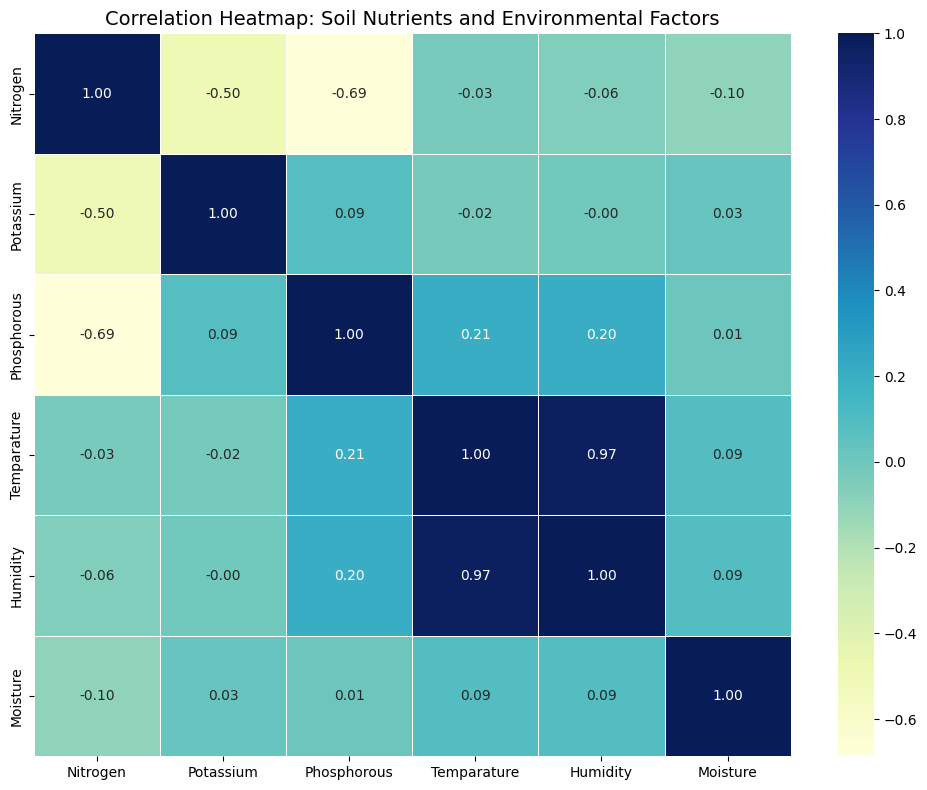

In [7]:
# 3. Create Correlation Heatmap
# This shows the relationship between N, P, K and Environmental factors
plt.figure(figsize=(10, 8))
# Selecting only numeric columns for correlation
correlation_cols = ['Nitrogen', 'Potassium', 'Phosphorous', 'Temparature', 'Humidity', 'Moisture']
corr_matrix = data[correlation_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Soil Nutrients and Environmental Factors', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
print("Heatmap saved as 'correlation_heatmap.png'")

C:\Users\Hp\AppData\Local\Temp\ipykernel_28096\3373300468.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.index, y=dist.values, palette='viridis')


Bar chart saved as 'fertilizer_distribution.png'


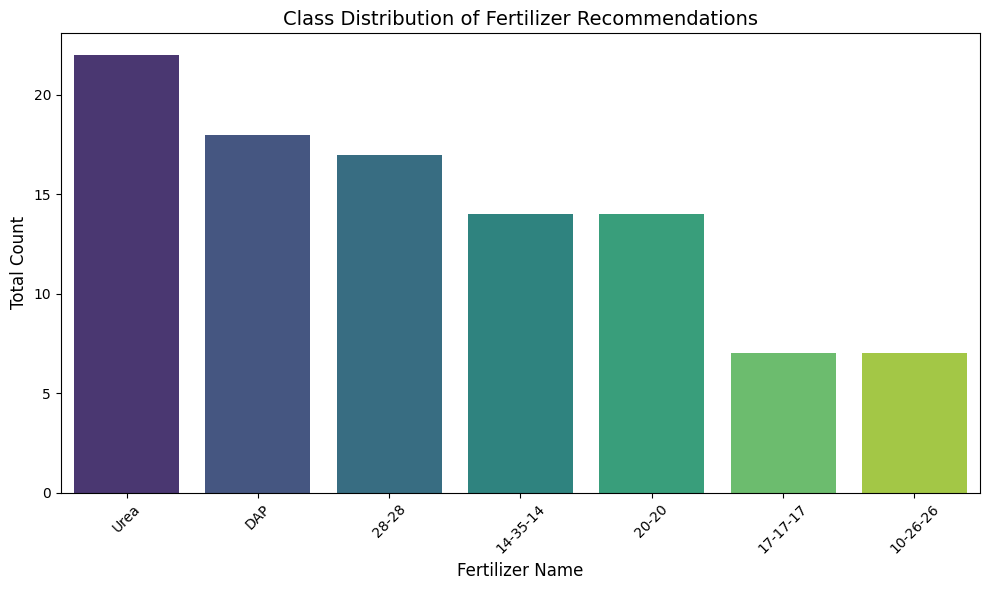

In [8]:
# 4. Create Bar Chart of Class Distribution
# This proves the dataset is balanced and shows the frequency of each fertilizer
plt.figure(figsize=(10, 6))
# Sort values for a professional look
dist = df['Fertilizer Name'].value_counts().sort_values(ascending=False)
sns.barplot(x=dist.index, y=dist.values, palette='viridis')

plt.title('Class Distribution of Fertilizer Recommendations', fontsize=14)
plt.xlabel('Fertilizer Name', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fertilizer_distribution.png', dpi=300)
print("Bar chart saved as 'fertilizer_distribution.png'")

In [9]:
data.duplicated().sum()


0

In [10]:
data.isnull().sum()


Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

# Encoding

In [11]:

le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()

data['Soil Type'] = le_soil.fit_transform(data['Soil Type'])
data['Crop Type'] = le_crop.fit_transform(data['Crop Type'])
data['Fertilizer Name'] = le_fert.fit_transform(data['Fertilizer Name'])


In [12]:
X = data.drop('Fertilizer Name', axis=1)
y = data['Fertilizer Name']


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


# Load Models

In [15]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naive Bayes": GaussianNB()
}


# Train and Evaluate Models

In [16]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.2f}")


Decision Tree Accuracy: 1.00
Random Forest Accuracy: 0.95
Naive Bayes Accuracy: 1.00


In [17]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("Error (MSE):", mse * 100)
    print("Fitting Score (R2):", r2 * 100)
    print("Accuracy:", acc * 100)



Decision Tree
Error (MSE): 0.0
Fitting Score (R2): 100.0
Accuracy: 100.0

Random Forest
Error (MSE): 20.0
Fitting Score (R2): 94.26523297491039
Accuracy: 95.0

Naive Bayes
Error (MSE): 0.0
Fitting Score (R2): 100.0
Accuracy: 100.0


# Best Model

In [18]:
best_model_name = max(models, key=lambda m: accuracy_score(y_test, models[m].predict(X_test)))
print("Best Model:", best_model_name)



Best Model: Decision Tree


In [19]:
joblib.dump(best_model_name, "fertilizer_model.pkl")

joblib.dump(le_fert, "fertilizer_encoder.pkl")
joblib.dump(le_soil, "soil_encoder.pkl")
joblib.dump(le_crop, "crop_encoder.pkl")



['crop_encoder.pkl']

In [21]:
# model = joblib.load("fertilizer_model.pkl")
# sample = [[26, 52, 38, 1, 2, 37, 0, 0]]

# sample_scaled = scaler.transform(sample)
# pred = model.predict(sample_scaled)

# print("Recommended Fertilizer:",
#       le_fert.inverse_transform(pred)[0])


In [ ]:
df.head() 


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea
